# Circuits for Lesson 7 of the Tutorial

The 14 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 7 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. AS7's Example 9.9

In this problem, we run an AC (phasor) analysis for the first time: find v(t) and i(t). The first AC problem. The source is the phasor of 10 cos(4t), and the capacitor is in farads, which is why the frequency is needed. Read ir1 and vc with the aa mini-tool, then convert back to sinusoids by hand.

![The circuit of AS7's Example 9.9](https://learn.symbulator.com/assets/circuit/as7e0909.png)

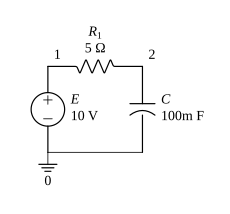

In [3]:
c1 = '''
e,1,0,10
r1,1,2,5
c,2,0,.1
'''
draw(c1)

In [4]:
r1 = ac(c1, omega=4)
r1.rounded(4)

Result(domain='ac')
  ap_e = -8.000
  ap_r1 = 8.000
  i_c = 1.6 + 0.8*I
  i_e = -1.6 - 0.8*I
  i_r1 = 1.6 + 0.8*I
  p_e = -8.000
  p_r1 = 8.000
  q_e = 4.000
  q_r1 = 0
  s_c = -4.0*I
  s_e = -8.0 + 4.0*I
  s_r1 = 8.000
  v_1 = 10.00
  v_2 = 2.0 - 4.0*I
  v_c = 2.0 - 4.0*I
  v_e = 10.00
  v_r1 = 8.0 + 4.0*I
  z_e = 5.0 - 2.5*I

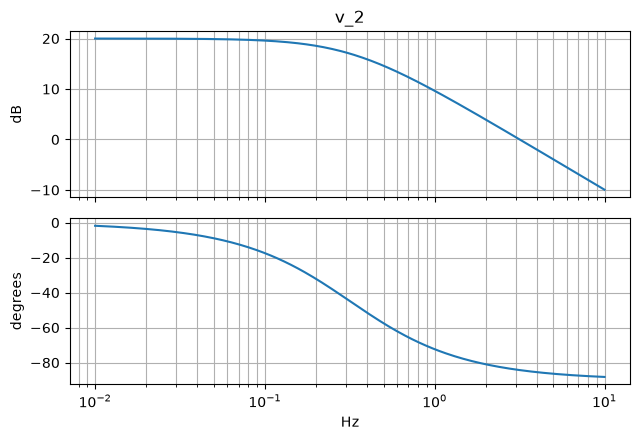

In [5]:
f, mag, phase = bode_samples(c1, 'v_2', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('v_2'); plt.tight_layout()

## 2. AS7's Practice Problem 9.9

Find v(t) and i(t) — read ir1 and vl. The source is written in polar form, which version 9 reads as typed.

![The circuit of AS7's Practice Problem 9.9](https://learn.symbulator.com/assets/circuit/as7pp0909.png)

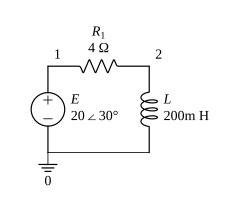

In [6]:
c2 = '''
e,1,0,(20∠30°)
r1,1,2,4
l,2,0,.2
'''
draw(c2)

In [7]:
r2 = ac(c2, omega=10)
r2.rounded(4)

Result(domain='ac')
  ap_e = -40.00
  ap_r1 = 40.00
  i_e = -4.464 - 0.2679*I
  i_l = 4.464 + 0.2679*I
  i_r1 = 4.464 + 0.2679*I
  p_e = -40.00
  p_r1 = 40.00
  q_e = -20.00
  q_r1 = 0
  s_e = -40.0 - 20.0*I
  s_l = 20.0*I
  s_r1 = 40.00
  v_1 = 17.32 + 10.0*I
  v_2 = -0.5359 + 8.928*I
  v_e = 17.32 + 10.0*I
  v_l = -0.5359 + 8.928*I
  v_r1 = 17.86 + 1.072*I
  z_e = 4.0 + 2.0*I

## 3. AS7's Example 9.10

Find the input impedance of the circuit at ω = 50 rad/s. A passive network, so the Resistance / impedance equivalent between nodes 1 and 0 does it: zeq = 3.22 - 11.07j ohm.

![The circuit of AS7's Example 9.10](https://learn.symbulator.com/assets/circuit/as7e0910.png)

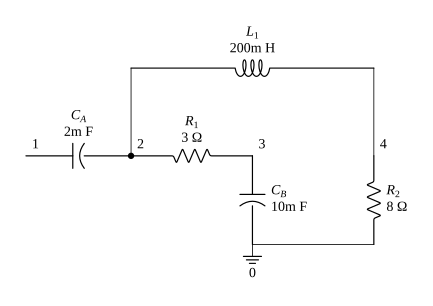

In [8]:
c3 = '''
ca,1,2,2'm
r1,2,3,3
cb,3,0,10'm
l1,2,4,.2
r2,4,0,8
'''
draw(c3)

In [9]:
r3 = er(c3, '1', '0', domain='ac', omega=50)
r3

3.22162162162162 - 11.0702702702703*I

## 4. AS7's Problem 9.35

Find the steady-state current i when vs = 50 cos(200t) V: aa(ir) gives 4.789 A at -16.7°.

![The circuit of AS7's Problem 9.35](https://learn.symbulator.com/assets/circuit/as7p0935.png)

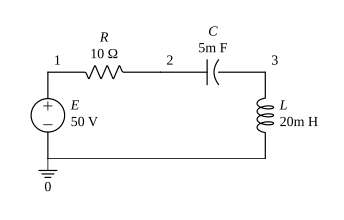

In [10]:
c4 = '''
e,1,0,50
r,1,2,10
c,2,3,5'm
l,3,0,20'm
'''
draw(c4)

In [11]:
r4 = ac(c4, omega=200)
r4.rounded(4)

Result(domain='ac')
  ap_e = -114.7
  ap_r = 114.7
  i_c = 4.587 - 1.376*I
  i_e = -4.587 + 1.376*I
  i_l = 4.587 - 1.376*I
  i_r = 4.587 - 1.376*I
  p_e = -114.7
  p_r = 114.7
  q_e = -34.40
  q_r = 0
  s_c = -11.47*I
  s_e = -114.7 - 34.4*I
  s_l = 45.87*I
  s_r = 114.7
  v_1 = 50
  v_2 = 4.128 + 13.76*I
  v_3 = 5.505 + 18.35*I
  v_c = -1.376 - 4.587*I
  v_e = 50
  v_l = 5.505 + 18.35*I
  v_r = 45.87 - 13.76*I
  z_e = 10.0 + 3.0*I

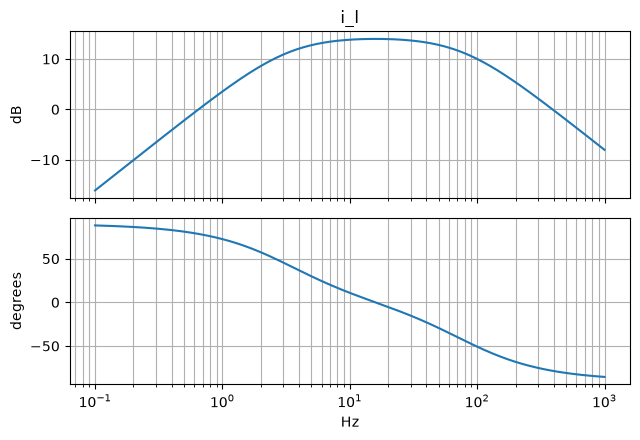

In [12]:
f, mag, phase = bode_samples(c4, 'i_l', 0.1, 1000, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

## 5. AS7's Problem 9.39

Find the equivalent impedance, and from it the current I. Every value is already an impedance, so the frequency is asked for but never used. The bracket shorthand does the parallel reduction inside the value.

![The circuit of AS7's Problem 9.39](https://learn.symbulator.com/assets/circuit/as7p0939.png)

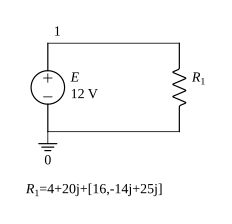

In [13]:
c5 = '''
e,1,0,12
r1,1,0,4+20j+[16,-14j+25j]
'''
draw(c5)

In [14]:
r5 = ac(c5, omega=1)
r5.rounded(4)

Result(domain='ac')
  ap_e = -0.7849
  ap_r1 = 0.7849
  i_e = -0.1308 + 0.3933*I
  i_r1 = 0.1308 - 0.3933*I
  p_e = -0.7849
  p_r1 = 0.7849
  q_e = -2.360
  q_r1 = 2.360
  s_e = -0.7849 - 2.36*I
  s_r1 = 0.7849 + 2.36*I
  v_1 = 12
  v_e = 12
  v_r1 = 12
  z_e = 9.135 + 27.47*I

## 6. AS7's Problem 9.73

Find the equivalent impedance between nodes 1 and 0: 0.3794 + 1.46j ohm. Eight impedances and no source, so this is the equivalent-impedance tool rather than a solve.

![The circuit of AS7's Problem 9.73](https://learn.symbulator.com/assets/circuit/as7p0973.png)

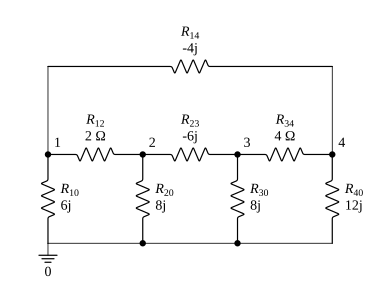

In [15]:
c6 = '''
r10,1,0,6j
r20,2,0,8j
r30,3,0,8j
r40,4,0,12j
r12,1,2,2
r23,2,3,-6j
r34,3,4,4
r14,1,4,-4j
'''
draw(c6)

In [16]:
r6 = er(c6, '1', '0', domain='ac', omega=1)
r6

58950/155357 + 226794*I/155357

## 7. AS7's Example 10.1 (Dependent source)

Find ix — the current through the capacitor cx, which also controls the current source: aa(icx) gives 7.589 A at 108.4°.

![The circuit of AS7's Example 10.1 (Dependent source)](https://learn.symbulator.com/assets/circuit/as7e1001.png)

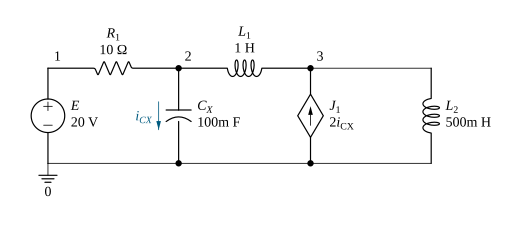

In [17]:
c7 = '''
e,1,0,20
r1,1,2,10
cx,2,0,.1
l1,2,3,1
j1,0,3,2*icx
l2,3,0,.5
'''
draw(c7)

In [18]:
r7 = ac(c7, omega=4)
r7.rounded(4)

Result(domain='ac')
  ap_e = -2.000
  ap_j1 = 0
  ap_r1 = 2.000
  i_cx = -2.4 + 7.2*I
  i_e = -0.2 + 0.6*I
  i_j1 = -4.8 + 14.4*I
  i_l1 = 2.6 - 7.8*I
  i_l2 = -2.2 + 6.6*I
  i_r1 = 0.2 - 0.6*I
  p_e = -2.000
  p_j1 = 0
  p_r1 = 2.000
  q_e = -6.000
  q_j1 = -105.6
  q_r1 = 0
  s_cx = -72.0*I
  s_e = -2.0 - 6.0*I
  s_j1 = -105.6*I
  s_l1 = 135.2*I
  s_l2 = 48.4*I
  s_r1 = 2.000
  v_1 = 20.00
  v_2 = 18.0 + 6.0*I
  v_3 = -13.2 - 4.4*I
  v_cx = 18.0 + 6.0*I
  v_e = 20.00
  v_j1 = 13.2 + 4.4*I
  v_l1 = 31.2 + 10.4*I
  v_l2 = -13.2 - 4.4*I
  v_r1 = 2.0 - 6.0*I
  z_e = 10.0 + 30.0*I
  z_j1 = 0.9167*I

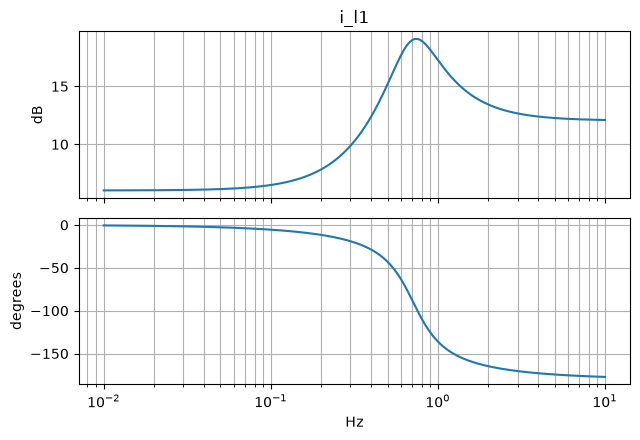

In [19]:
f, mag, phase = bode_samples(c7, 'i_l1', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l1'); plt.tight_layout()

## 8. AS7's Practice Problem 10.1 (Dependent source)

Find v1 and v2; the dependent source is controlled by the voltage across rx this time.

![The circuit of AS7's Practice Problem 10.1 (Dependent source)](https://learn.symbulator.com/assets/circuit/as7pp1001.png)

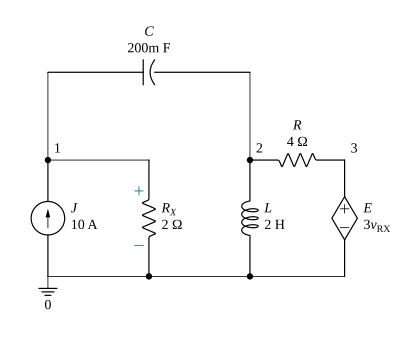

In [20]:
c8 = '''
j,0,1,10
rx,1,0,2
c,1,2,.2
l,2,0,2
r,2,3,4
e,3,0,3*vrx
'''
draw(c8)

In [21]:
r8 = ac(c8, omega=2)
r8.rounded(4)

Result(domain='ac')
  ap_e = -4.245
  ap_j = -28.30
  ap_r = 0.4717
  ap_rx = 32.08
  i_c = 7.17 - 4.906*I
  i_e = 0.2358 - 0.4245*I
  i_j = 10
  i_l = 6.934 - 4.481*I
  i_r = 0.2358 - 0.4245*I
  i_rx = 2.83 + 4.906*I
  p_e = -4.245
  p_j = -28.30
  p_r = 0.4717
  p_rx = 32.08
  q_e = 7.075
  q_j = -49.06
  q_r = 0
  q_rx = 0
  s_c = -94.34*I
  s_e = -4.245 + 7.075*I
  s_j = -28.3 - 49.06*I
  s_l = 136.3*I
  s_r = 0.4717
  s_rx = 32.08
  v_1 = 5.66 + 9.811*I
  v_2 = 17.92 + 27.74*I
  v_3 = 16.98 + 29.43*I
  v_c = -12.26 - 17.92*I
  v_e = 16.98 + 29.43*I
  v_j = -5.66 - 9.811*I
  v_l = 17.92 + 27.74*I
  v_r = 0.9434 - 1.698*I
  v_rx = 5.66 + 9.811*I
  z_e = 36.0 - 60.0*I
  z_j = 0.566 + 0.9811*I

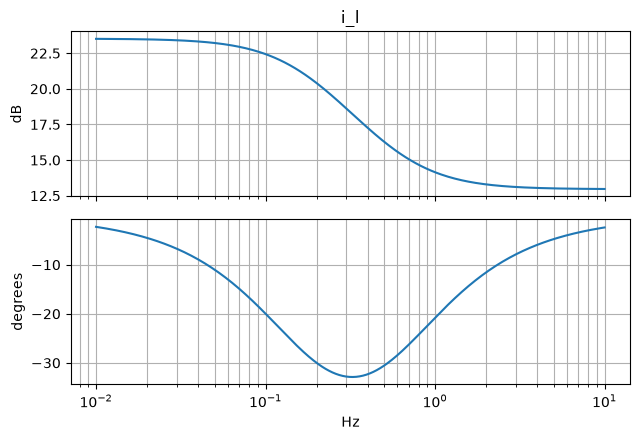

In [22]:
f, mag, phase = bode_samples(c8, 'i_l', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

## 9. AS7's Example 10.13 (Dependent source)

Find vo and io — read vro and ico with aa: 1.55 V at -95.18° and 3.26 mA at -3.74°.

![The circuit of AS7's Example 10.13 (Dependent source)](https://learn.symbulator.com/assets/circuit/as7e1013.png)

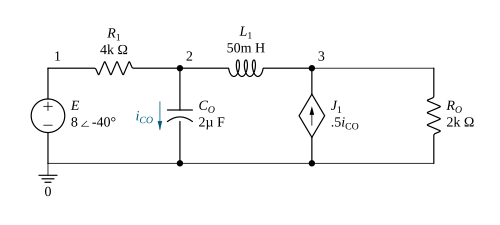

In [23]:
c9 = '''
e,1,0,(8∠-40°)
r1,1,2,4'k
co,2,0,2'µ
l1,2,3,50'm
j1,0,3,.5*ico
ro,3,0,2'k
'''
draw(c9)

In [24]:
r9 = ac(c9, omega=1000)
r9.rounded(4)

Result(domain='ac')
  ap_e = -0.007035
  ap_j1 = 0.00003161
  ap_r1 = 0.006402
  ap_ro = 0.0006006
  i_co = 0.003257 - 0.0002131*I
  i_e = -0.001559 + 0.0008784*I
  i_j1 = 0.001629 - 0.0001066*I
  i_l1 = -0.001699 - 0.0006653*I
  i_r1 = 0.001559 - 0.0008784*I
  i_ro = -6.991e-5 - 0.0007719*I
  p_e = -0.007035
  p_j1 = 0.00003161
  p_r1 = 0.006402
  p_ro = 0.0006006
  q_e = 0.001316
  q_j1 = 0.001265
  q_r1 = 0
  q_ro = 0
  s_co = -0.002664*I
  s_e = -0.007035 + 0.001316*I
  s_j1 = 3.161e-5 + 0.001265*I
  s_l1 = 8.319e-5*I
  s_r1 = 0.006402
  s_ro = 0.0006006
  v_1 = 6.128 - 5.142*I
  v_2 = -0.1066 - 1.629*I
  v_3 = -0.1398 - 1.544*I
  v_co = -0.1066 - 1.629*I
  v_e = 6.128 - 5.142*I
  v_j1 = 0.1398 + 1.544*I
  v_l1 = 0.03326 - 0.08493*I
  v_r1 = 6.235 - 3.514*I
  v_ro = -0.1398 - 1.544*I
  z_e = 4395.0 - 822.2*I
  z_j1 = -23.74 - 949.4*I

## 10. AS7's Example 10.14 (Dependent source)

Find V1 and V2. Values all in ohms again, so the frequency does not matter.

![The circuit of AS7's Example 10.14 (Dependent source)](https://learn.symbulator.com/assets/circuit/as7e1014.png)

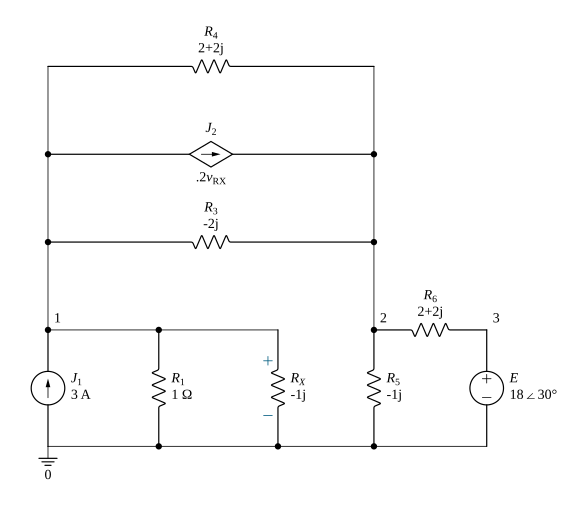

In [25]:
c10 = '''
j1,0,1,3
r1,1,0,1
rx,1,0,-1j
r3,1,2,-2j
j2,1,2,.2*vrx
r4,1,2,2+2j
r5,2,0,-1j
r6,2,3,2+2j
e,3,0,(18∠30°)
'''
draw(c10)

In [26]:
r10 = ac(c10, omega=1)
r10.rounded(4)

Result(domain='ac')
  ap_e = -60.55
  ap_j1 = -2.229
  ap_j2 = -0.9776
  ap_r1 = 3.668
  ap_r3 = 0
  ap_r4 = 2.615
  ap_r5 = 0
  ap_r6 = 57.48
  ap_rx = 0
  i_e = -7.574 - 0.338*I
  i_j1 = 3
  i_j2 = 0.2971 - 0.4529*I
  i_r1 = 1.486 - 2.265*I
  i_r3 = -2.279 + 0.1844*I
  i_r4 = 1.232 + 1.047*I
  i_r5 = 6.823 + 1.117*I
  i_r6 = -7.574 - 0.338*I
  i_rx = 2.265 + 1.486*I
  p_e = -60.55
  p_j1 = -2.229
  p_j2 = -0.9776
  p_r1 = 3.668
  p_r3 = 0
  p_r4 = 2.615
  p_r5 = 0
  p_r6 = 57.48
  p_rx = 0
  q_e = -31.45
  q_j1 = 3.397
  q_j2 = 0.7608
  q_r1 = 0
  q_r3 = -5.230
  q_r4 = 2.615
  q_r5 = -23.90
  q_r6 = 57.48
  q_rx = -3.668
  s_e = -60.55 - 31.45*I
  s_j1 = -2.229 + 3.397*I
  s_j2 = -0.9776 + 0.7608*I
  s_r1 = 3.668
  s_r3 = -5.23*I
  s_r4 = 2.615 + 2.615*I
  s_r5 = -23.9*I
  s_r6 = 57.48 + 57.48*I
  s_rx = -3.668*I
  v_1 = 1.486 - 2.265*I
  v_2 = 1.117 - 6.823*I
  v_3 = 15.59 + 9.0*I
  v_e = 15.59 + 9.0*I
  v_j1 = -1.486 + 2.265*I
  v_j2 = 0.3688 + 4.559*I
  v_r1 = 1.486 - 2.265*I
  v

## 11. AS7's Problem 9.89 (at 2 kHz, as the book asks)

Find the C that makes the net impedance purely resistive at 2 kHz: solve im(zeq) = 0 for c, which gives 1.235 µF — not the book's answer. The omega box takes an expression, so the frequency in hertz can be converted in place. Real solutions only, or the answer carries an im(c) term.

![The circuit of AS7's Problem 9.89 (at 2 kHz, as the book asks)](https://learn.symbulator.com/assets/circuit/as7p0989.png)

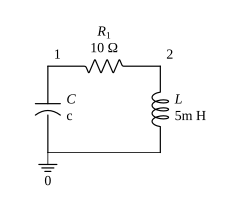

In [27]:
c11 = '''
c,1,0,c
r1,1,2,10
l,2,0,5'm
'''
draw(c11)

In [28]:
r11 = er(c11, '1', '0', domain='ac', omega=sp.sympify('2*pi*2e3'))
r11

(10.0 + 62.8318530717959*I)/(c*(-789568.352087149 + 125663.706143592*I) + 1.0)

*In the app this entry also uses Solve, which this notebook does not reproduce yet.*

## 12. AS7's Problem 9.89 (at 2000 rad/s, as it was meant)

The same solve at 2000 rad/s gives c = 25 — the book's 25 µF. The capacitance is declared as c'u, so the answer comes out in microfarads. Roberto's reading is that the book asked for 2 kHz when it meant 2000 rad/s.

![The circuit of AS7's Problem 9.89 (at 2000 rad/s, as it was meant)](https://learn.symbulator.com/assets/circuit/as7p0989.png)

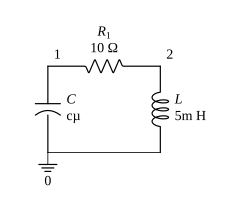

In [29]:
c12 = '''
c,1,0,c'µ
r1,1,2,10
l,2,0,5'm
'''
draw(c12)

In [30]:
r12 = er(c12, '1', '0', domain='ac', omega=2000)
r12

500*I/(-c + 25 + 25*I)

*In the app this entry also uses Solve, which this notebook does not reproduce yet.*

## 13. AS7's Problem 10.69 (Symbolic)

Find Vo/Vs symbolically: -c*omega*r*j. The omega box takes a name as readily as a number, so the answer comes back as a function of it.

![The circuit of AS7's Problem 10.69 (Symbolic)](https://learn.symbulator.com/assets/circuit/as7p1069.png)

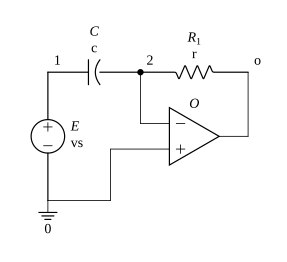

In [31]:
c13 = '''
e,1,0,vs
c,1,2,c
r1,2,o,r
o,0,2,o
'''
draw(c13)

In [32]:
r13 = ac(c13, omega='omega')
r13

Result(domain='ac')
  ap_e = -im(conjugate(c)*conjugate(omega))*Abs(vs)**2/2
  ap_o = -re(r)*Abs(c**2*omega**2*vs**2)/2
  ap_r1 = re(r)*Abs(c**2*omega**2*vs**2)/2
  i_c = I*c*omega*vs
  i_e = -I*c*omega*vs
  i_o = -I*c*omega*vs
  i_r1 = I*c*omega*vs
  p_e = -im(conjugate(c)*conjugate(omega))*Abs(vs)**2/2
  p_o = -re(r)*Abs(c**2*omega**2*vs**2)/2
  p_r1 = re(r)*Abs(c**2*omega**2*vs**2)/2
  q_e = re(conjugate(c)*conjugate(omega))*Abs(vs)**2/2
  q_o = -im(r)*Abs(c**2*omega**2*vs**2)/2
  q_r1 = im(r)*Abs(c**2*omega**2*vs**2)/2
  s_c = -I*vs*conjugate(c)*conjugate(omega)*conjugate(vs)/2
  s_e = I*vs*conjugate(c)*conjugate(omega)*conjugate(vs)/2
  s_o = -c*omega*r*vs*conjugate(c)*conjugate(omega)*conjugate(vs)/2
  s_r1 = c*omega*r*vs*conjugate(c)*conjugate(omega)*conjugate(vs)/2
  v_1 = vs
  v_2 = 0
  v_c = vs
  v_e = vs
  v_o = -I*c*omega*r*vs
  v_r1 = I*c*omega*r*vs
  z_e = -I/(c*omega)

*In the app this entry also uses Evaluate, which this notebook does not reproduce yet.*

## 14. AS7's Problem 10.77 (Symbolic)

Compute the closed-loop gain Vo/Vs with every value a symbol. Everything symbolic including the frequency -- about the limit of what is worth solving this way.

![The circuit of AS7's Problem 10.77 (Symbolic)](https://learn.symbulator.com/assets/circuit/as7pr1077.png)

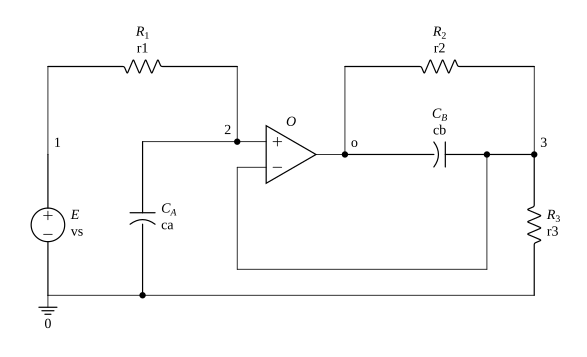

In [33]:
c14 = '''
e,1,0,vs
r1,1,2,r1
ca,2,0,ca
r3,0,3,r3
o,2,3,o
cb,3,o,cb
r2,3,o,r2
'''
draw(c14)

In [34]:
r14 = ac(c14, omega='omega')
r14

Result(domain='ac')
  ap_e = -re(conjugate(ca)*conjugate(omega)/(conjugate(ca)*conjugate(omega)*conjugate(r1) + I))*Abs(vs)**2/2
  ap_o = ((re(r2) + re(r3) - im(cb*omega*r2*r3))*im(1/((conjugate(ca)*conjugate(omega)*conjugate(r1) + I)*(-ca*cb*omega**2*r1*r2 + I*ca*omega*r1 + I*cb*omega*r2 + 1))) + (re(cb*omega*r2*r3) + im(r2) + im(r3))*re(1/((conjugate(ca)*conjugate(omega)*conjugate(r1) + I)*(-ca*cb*omega**2*r1*r2 + I*ca*omega*r1 + I*cb*omega*r2 + 1))))*Abs(vs**2/r3**2)/2
  ap_r1 = re(r1)*Abs(ca**2*omega**2*vs**2)/(2*(ca*omega*r1*conjugate(ca)*conjugate(omega)*conjugate(r1) + I*ca*omega*r1 - I*conjugate(ca)*conjugate(omega)*conjugate(r1) + 1))
  ap_r2 = -re(r2/((-ca*cb*omega**2*r1*r2 + I*ca*omega*r1 + I*cb*omega*r2 + 1)*(conjugate(ca)*conjugate(cb)*conjugate(omega)**2*conjugate(r1)*conjugate(r2) + I*conjugate(ca)*conjugate(omega)*conjugate(r1) + I*conjugate(cb)*conjugate(omega)*conjugate(r2) - 1)))*Abs(vs**2/r3**2)/2
  ap_r3 = re(r3)*Abs(vs)**2/(2*(re(r3)**2 + im(r3)**2)*(ca*omega*r1*c

*In the app this entry also uses Evaluate, which this notebook does not reproduce yet.*